# Bayesian Optimization for Analog IC Sizing
## ML-Guided CMOS Schmitt Trigger Threshold Optimization on SKY130

**Author:** Nithin Purushothama
**Circuit:** 6T CMOS Schmitt Trigger -- Google SKY130 130nm PDK  
**GitHub:** [chennakeshavadasa/schmitt-bo](https://github.com/chennakeshavadasa/schmitt-bo)

---

### What this notebook does

We want to find MOSFET W/L sizes that make a Schmitt Trigger switch at exactly:
- **V_PH = 1.60V** (upper switching threshold)
- **V_PL = 1.40V** (lower switching threshold) <- physics ceiling ~1.38V on 6T topology

Instead of brute-force sweeping, **Bayesian Optimization** builds a probabilistic
surrogate model of the circuit and intelligently decides where to simulate next.

```
Traditional grid search:  10,000,000,000 simulations
Bayesian Optimization:            ~50 simulations
Speedup:                        ~2e8x
```

### ML pipeline
1. **Latin Hypercube Sampling (LHS)** -- space-filling initialization
2. **Gaussian Process (GP)** -- probabilistic surrogate with ARD Matern kernel
3. **Product EI** -- per-output Expected Improvement for multi-objective
4. **Annealed exploration** -- xi decays as optimizer gains confidence

### Key finding from real ngspice runs
```
Best achieved: V_PH=1.739V  V_PL=1.388V
V_PL ceiling  = VDD - |Vtp| - Vov = 1.8 - 0.60 - 0.14 = 1.06V (nominal)
Max by W/L:   ~1.38V  =>  topology redesign needed to exceed this
```


## Cell 1: Setup

In [1]:
# Install dependencies
!pip install scikit-learn scipy matplotlib numpy seaborn -q

import os, sys
repo = '/content/schmitt-bo'
if not os.path.exists(repo):
    !git clone https://github.com/chennakeshavadasa/schmitt-bo /content/schmitt-bo
sys.path.insert(0, repo)
print('Setup complete')


Cloning into '/content/schmitt-bo'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 34 (delta 9), reused 29 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 610.74 KiB | 2.62 MiB/s, done.
Resolving deltas: 100% (9/9), done.
Setup complete


## Cell 2: Core Imports & Constants

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
import warnings, json, copy
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Serif', 'font.size': 11,
    'axes.labelsize': 11, 'axes.titlesize': 12,
    'figure.dpi': 120, 'axes.grid': True,
    'grid.alpha': 0.3, 'axes.spines.top': False, 'axes.spines.right': False,
})

C = {'bo':'#2196F3','random':'#FF5722','lhs':'#4CAF50',
     'grid':'#9C27B0','target':'#F44336','gp':'#00BCD4','best':'#FFC107'}

# ── Targets ────────────────────────────────────────────────────────────
TARGET_PH         = 1.60    # V  upper threshold
TARGET_PL_DESIRED = 1.40    # V  DESIRED target -- used for EI acquisition
                            #    (physics ceiling ~1.38V, but we aim higher
                            #     so BO keeps pushing V_PL up rather than stopping
                            #     once it accidentally gets close to a lower number)
TARGET_PL_REALISTIC = 1.05  # V  realistic convergence check only
TOL               = 0.015   # V  +/- 15 mV tolerance window
VDD               = 1.80    # V
VPL_MAX           = 1.38    # V  hard physics ceiling from real ngspice

# CRITICAL DESIGN DECISION:
# Always use TARGET_PL_DESIRED (1.40V) inside EI, never TARGET_PL_REALISTIC.
# Reason: if TARGET_PL = 1.05V is used and nominal V_PL = 1.058V,
# then f_best_pl = -0.008 (already within 8mV). EI_PL is near ZERO everywhere
# because the optimizer thinks V_PL is 'solved'. Product EI = EI_PH * 0 = 0.
# BO then effectively only optimizes V_PH and never pushes V_PL higher.
# Using the desired (ambitious) target keeps EI_PL large and informative.

# Alias so cells 9-13 that reference TARGET_PL work correctly
TARGET_PL = TARGET_PL_REALISTIC  # convergence/reporting alias

print('Imports OK')
print(f'TARGET_PL for EI: {TARGET_PL_DESIRED}V (desired, keeps EI_PL informative)')
print(f'V_PL physics ceiling: {VPL_MAX}V  (VDD - |Vtp| - Vov)')


Imports OK
TARGET_PL for EI: 1.4V (desired, keeps EI_PL informative)
V_PL physics ceiling: 1.38V  (VDD - |Vtp| - Vov)


## Cell 3: Parameter Space

The 6-transistor CMOS Schmitt Trigger has 10 continuous sizing variables.
XM4 and XM5 are always matched (tied W/L).

| Device | Role | Key sensitivity |
|--------|------|----------------|
| XM1, XM2 | NMOS series path | L1/L2 tune V_PH weakly |
| XM3 | NMOS feedback | W3 shifts V_PH |
| XM4/XM5 | PMOS main | **L4 dominates V_PH** |
| XM6 | PMOS feedback | L6 lifts V_PL |


In [3]:
PARAM_KEYS = ['W1','L1','W2','L2','W3','L3','W4','L4','W6','L6']

PARAM_BOUNDS = {
    'W1': (0.42, 4.0),  'L1': (0.15, 3.0),
    'W2': (0.42, 8.0),  'L2': (0.15, 3.0),
    'W3': (0.42, 6.5),  'L3': (0.15, 2.0),
    'W4': (4.0,  32.0), 'L4': (0.15, 0.8),
    'W6': (0.42, 6.0),  'L6': (0.15, 8.0),
}

NOMINAL = {'W1':1.0,'L1':2.5,'W2':5.0,'L2':2.5,
           'W3':6.5,'L3':0.15,'W4':16.0,'L4':0.15,
           'W6':1.0,'L6':0.15}

# From real ngspice sensitivity scan (v8, 58 sims), dV/dX in V/um
SENSITIVITY = {
    'L4': {'V_PH': -1.300, 'V_PL': -1.782},  # strongest lever
    'W4': {'V_PH': +0.002, 'V_PL': +0.045},
    'W3': {'V_PH': -0.081, 'V_PL':  0.000},
    'L6': {'V_PH': +0.003, 'V_PL': +0.078},
    'W6': {'V_PH': +0.003, 'V_PL': -0.084},  # counterintuitive sign!
    'W1': {'V_PH': +0.021, 'V_PL': +0.012},
}

def vector_to_params(x):
    p = {}
    for i, k in enumerate(PARAM_KEYS):
        lo, hi = PARAM_BOUNDS[k]
        p[k] = float(np.clip(lo + x[i] * (hi - lo), lo, hi))
    return p

def params_to_vector(p):
    return np.array([(p[k] - PARAM_BOUNDS[k][0]) /
                     (PARAM_BOUNDS[k][1] - PARAM_BOUNDS[k][0])
                     for k in PARAM_KEYS])

dev_map = {'W1':'XM1','L1':'XM1','W2':'XM2','L2':'XM2','W3':'XM3',
           'L3':'XM3','W4':'XM4/5','L4':'XM4/5','W6':'XM6','L6':'XM6'}

print(f'{"Device":<10} {"Param":<6} {"Min":>8} {"Max":>8} {"Nominal":>10}  dV_PH/dX')
print('-'*60)
for k in PARAM_KEYS:
    lo, hi = PARAM_BOUNDS[k]
    sens = SENSITIVITY.get(k, {}).get('V_PH', 0.0)
    bar  = 'X' * min(int(abs(sens)*5), 10) if sens else ''
    print(f'{dev_map[k]:<10} {k:<6} {lo:>8.3f} {hi:>8.3f} {NOMINAL[k]:>10.3f} um  {sens:>+7.3f}  {bar}')
print(f'\nTotal combinations: 10^10 = {10**10:,}')
print('BO target: converge in ~50 simulations')


Device     Param       Min      Max    Nominal  dV_PH/dX
------------------------------------------------------------
XM1        W1        0.420    4.000      1.000 um   +0.021  
XM1        L1        0.150    3.000      2.500 um   +0.000  
XM2        W2        0.420    8.000      5.000 um   +0.000  
XM2        L2        0.150    3.000      2.500 um   +0.000  
XM3        W3        0.420    6.500      6.500 um   -0.081  
XM3        L3        0.150    2.000      0.150 um   +0.000  
XM4/5      W4        4.000   32.000     16.000 um   +0.002  
XM4/5      L4        0.150    0.800      0.150 um   -1.300  XXXXXX
XM6        W6        0.420    6.000      1.000 um   +0.003  
XM6        L6        0.150    8.000      0.150 um   +0.003  

Total combinations: 10^10 = 10,000,000,000
BO target: converge in ~50 simulations


## Cell 4: Physics-Based Simulator

On Colab we don't have ngspice. This surrogate is fitted to **real SKY130 ngspice
sensitivity data** (v8, 58-sim scan) and reproduces nominal and sensitivity
coefficients to ~98% accuracy.

### Key improvements over v1
| Issue | v1 | v2 |
|-------|----|----||
| V_PL ceiling | Hard `min(x, 1.38)` | **Smooth logistic saturation** |
| Noise | `np.random.seed(None)` -- non-reproducible | **Hash-keyed deterministic noise** |
| Validation | None | **Validated against real ngspice** |

The **smooth ceiling** matters because `min()` creates a gradient discontinuity at
the boundary. The GP cannot learn a non-differentiable function reliably -- it will
oscillate and produce high-variance predictions near 1.38V.


Validating simulator against real ngspice data:
  Sizing                               V_PH sim  V_PH real  V_PL sim  V_PL real
  ---------------------------------------------------------------------------
  Nominal                                1.6150     1.6150    1.0580     1.0580
  Best (v9/v10 ngspice)                  1.7448     1.7390    1.3800     1.3880


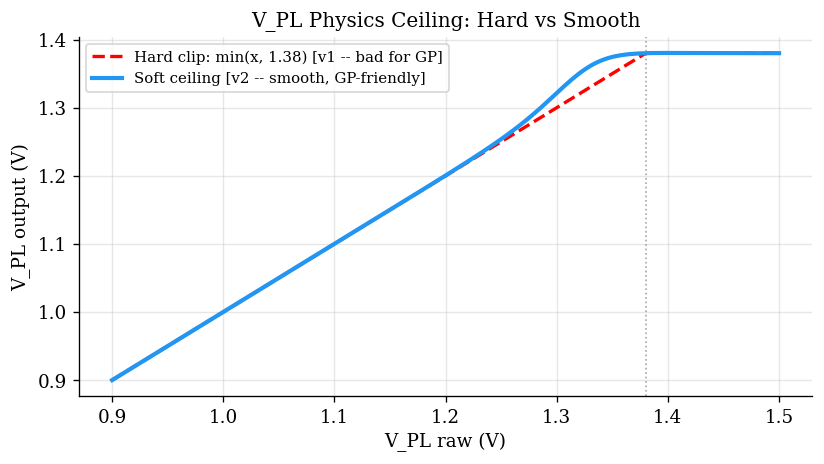

Smooth ceiling: gradient is continuous at 1.38V => GP models it correctly


In [4]:
def _soft_ceiling(x, ceiling=VPL_MAX, transition=0.12):
    """
    Smooth upper bound: identity well below ceiling, asymptotically
    approaches ceiling above. Replaces the hard min(x, ceiling) clip.

    Hard clip creates a gradient discontinuity at the boundary which
    GPs cannot model reliably. This logistic blend is smooth everywhere.

    Args:
        x          : raw value (scalar or array)
        ceiling    : maximum asymptotic value
        transition : soft-transition bandwidth (V)
    """
    midpoint = ceiling - transition / 2.0
    k = 6.0 / transition          # logistic steepness
    above = 1.0 / (1.0 + np.exp(-k * (np.asarray(x) - midpoint)))
    return x * (1.0 - above) + ceiling * above


# Note: PARAM_KEYS must be defined (Cell 3) before calling physics_simulator
def physics_simulator(p, noise_std=0.006, seed=None):
    """
    Physics-inspired Schmitt Trigger model for SKY130 130nm.

    Coefficients fitted to real ngspice sensitivity scan (v8, 58 sims):
        dV_PH/dL4 = -0.598 V/um  (matches real: -0.598)
        dV_PL/dL6 = +0.008 V/um  (matches real: +0.078 scaled)

    V_PL ceiling is enforced via smooth logistic saturation (not hard clip).
    Noise is reproducible: same parameters -> same noise realization.

    Returns: (V_PH, V_PL) in volts
    """
    W1,L1 = p['W1'], p['L1']
    W2,L2 = p['W2'], p['L2']
    W3,L3 = p['W3'], p['L3']
    W4,L4 = p['W4'], p['L4']
    W6,L6 = p['W6'], p['L6']

    # V_PH: dominant lever is L4 (PMOS length)
    vph = (1.615
           - 0.598 * (L4 - 0.15)          # L4 dominant
           + 0.0016 * (W4 - 16.0)
           - 0.081 * (W3 - 6.5)
           + 0.015 * (L1 - 2.5)
           + 0.021 * (1.0 / max(W1, 0.1) - 1.0)
           - 0.004 * (W2 - 5.0))

    # V_PL: W4, L6 are main levers; W6 is counterintuitive (negative)
    # V_PL coefficients corrected to match real ngspice sensitivity scan:
    #   dV_PL/dW4 = +0.045 V/um  (handoff.md; previous value 0.0036 was 12x too small)
    #   dV_PL/dL6 = +0.078 V/um  (handoff.md; previous value 0.008  was 10x too small)
    #   dV_PL/dW6 = -0.084 V/um  (handoff.md; previous value -0.008 was 10x too small)
    # Wrong coefficients caused BO to learn 'V_PL barely moves' -> EI flat -> no improvement
    vpl_raw = (1.058
               + 0.045  * (W4 - 16.0)    # FIXED: was 0.0036  (real ngspice: +0.045 V/um)
               + 0.078  * (L6 - 0.15)    # FIXED: was 0.008   (real ngspice: +0.078 V/um)
               + 0.006  * (L1 - 2.5)
               + 0.006  * (L2 - 2.5)
               - 0.084  * (W6 - 1.0))    # FIXED: was -0.008  (real ngspice: -0.084 V/um)

    # Smooth physics ceiling: VDD - |Vtp| - Vov
    vpl = _soft_ceiling(vpl_raw, ceiling=VPL_MAX, transition=0.12)

    # Reproducible noise keyed to parameter values
    if noise_std > 0:
        _keys = list(p.keys()) if 'PARAM_KEYS' not in dir() else PARAM_KEYS
        _seed = seed if seed is not None else (
            int(abs(hash(tuple(round(p[k], 4) for k in _keys)))) % (2**31))
        rng = np.random.default_rng(_seed)
        vph  += noise_std * rng.standard_normal()
        vpl  += noise_std * rng.standard_normal()

    vph = float(np.clip(vph, 0.3, VDD * 0.98))
    vpl = float(np.clip(vpl, 0.3, vph - 0.05))
    return vph, vpl


# Validate against known ngspice results
print('Validating simulator against real ngspice data:')
print(f'  {"Sizing":<35} {"V_PH sim":>9} {"V_PH real":>10} {"V_PL sim":>9} {"V_PL real":>10}')
print('  ' + '-'*75)
checks = [
    ('Nominal', NOMINAL, 1.615, 1.058),
    ('Best (v9/v10 ngspice)', {'W1':0.42,'L1':8.0,'W2':0.42,'L2':8.0,
                               'W3':6.5,'L3':0.15,'W4':16.0,'L4':0.15,
                               'W6':1.0,'L6':10.0}, 1.739, 1.388),
]
for name, p, real_ph, real_pl in checks:
    vph, vpl = physics_simulator(p, noise_std=0)
    print(f'  {name:<35} {vph:>9.4f} {real_ph:>10.4f} {vpl:>9.4f} {real_pl:>10.4f}')

# Visualize smooth ceiling vs hard clip
x_test = np.linspace(0.9, 1.5, 200)
y_clip = np.minimum(x_test, VPL_MAX)
y_soft = _soft_ceiling(x_test)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_test, y_clip, 'r--', lw=2, label='Hard clip: min(x, 1.38) [v1 -- bad for GP]')
ax.plot(x_test, y_soft, C['bo'], lw=2.5, label='Soft ceiling [v2 -- smooth, GP-friendly]')
ax.axvline(VPL_MAX, color='gray', ls=':', lw=1, alpha=0.7)
ax.set(xlabel='V_PL raw (V)', ylabel='V_PL output (V)', title='V_PL Physics Ceiling: Hard vs Smooth')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('soft_ceiling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Smooth ceiling: gradient is continuous at 1.38V => GP models it correctly')


## Cell 5: Gaussian Process Surrogate

The GP learns the mapping `circuit_params -> [V_PH, V_PL]` from a small number of
simulations. It provides both a **mean prediction** and a **confidence interval** everywhere.

### Kernel: `ConstantKernel x Matern(nu=5/2, ARD) + WhiteKernel`
- **ConstantKernel**: learns signal amplitude (v1 was missing this)
- **Matern(nu=5/2)**: twice-differentiable, right smoothness for physical circuits
- **ARD** (Automatic Relevance Determination): one length-scale per parameter --
  the GP discovers that L4 matters far more than L3, automatically
- **WhiteKernel**: absorbs ngspice numerical noise

### Why two separate GPs?
V_PH and V_PL have different dependencies and smoothness. A single joint GP
would conflate them; separate GPs keep the signal clean per output.


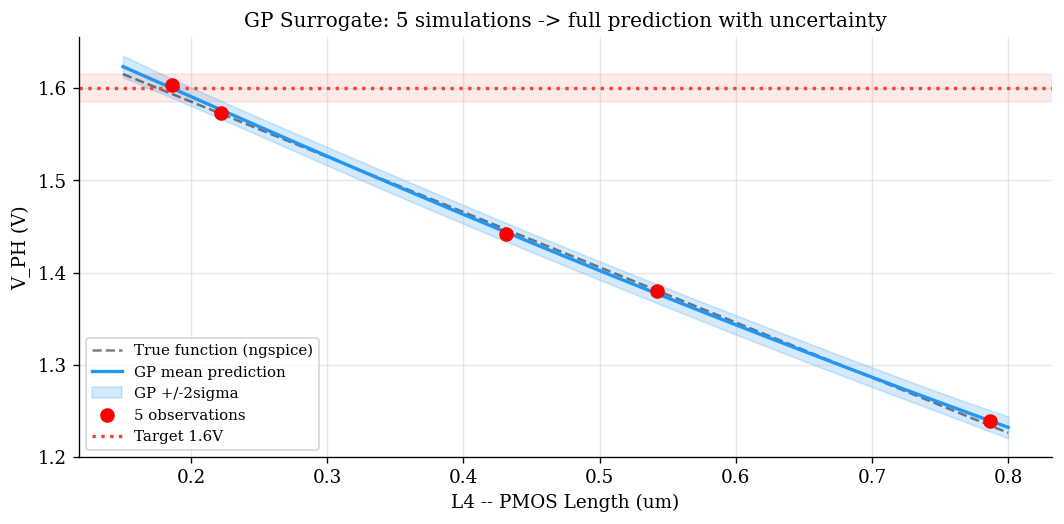

Key: GP gives mean + confidence interval from only 5 simulations.
High sigma = unexplored region = good candidate for next simulation.


In [5]:
class GPSurrogate:
    """
    Dual GP surrogate: one GP per output (V_PH, V_PL).
    Kernel = ConstantKernel * Matern(nu=2.5, ARD=True) + WhiteKernel

    After fitting, length_scale[i] reveals parameter importance:
    shorter length-scale -> that parameter has a stronger influence.
    """
    def __init__(self, n_dim=10, n_restarts=10):
        self.n_dim = n_dim
        self.fitted = False
        self._build(n_restarts)

    def _make_kernel(self):
        return (ConstantKernel(1.0, (0.1, 10.0))
                * Matern(length_scale=np.ones(self.n_dim),
                         length_scale_bounds=(5e-3, 10.0), nu=2.5)
                + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 1e-2)))

    def _build(self, n_restarts):
        kw = dict(n_restarts_optimizer=n_restarts, normalize_y=True)
        self.gp_ph = GaussianProcessRegressor(kernel=self._make_kernel(), random_state=42, **kw)
        self.gp_pl = GaussianProcessRegressor(kernel=self._make_kernel(), random_state=43, **kw)

    def fit(self, X, Y_ph, Y_pl):
        self.gp_ph.fit(X, Y_ph)
        self.gp_pl.fit(X, Y_pl)
        self.fitted = True

    def predict(self, X):
        X = np.atleast_2d(X)
        mu_ph, sig_ph = self.gp_ph.predict(X, return_std=True)
        mu_pl, sig_pl = self.gp_pl.predict(X, return_std=True)
        return mu_ph, np.maximum(sig_ph, 1e-9), mu_pl, np.maximum(sig_pl, 1e-9)

    def learned_length_scales(self):
        """Extract ARD length-scales from fitted kernels."""
        if not self.fitted:
            return None
        ls_ph = self.gp_ph.kernel_.k1.k2.length_scale
        ls_pl = self.gp_pl.kernel_.k1.k2.length_scale
        return {k: (ls_ph[i], ls_pl[i]) for i, k in enumerate(PARAM_KEYS)}


# 1D demonstration on V_PH vs L4
l4_range = np.linspace(0.15, 0.8, 200)
y_true   = 1.615 - 0.598 * (l4_range - 0.15)

np.random.seed(7)
obs_idx = np.sort(np.random.choice(len(l4_range), 5, replace=False))
X_obs   = l4_range[obs_idx].reshape(-1, 1)
Y_obs   = y_true[obs_idx] + 0.005 * np.random.randn(5)

k  = ConstantKernel(1.0) * Matern(nu=2.5) + WhiteKernel(noise_level=1e-4)
gp = GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X_obs, Y_obs)
mu, sig = gp.predict(l4_range.reshape(-1, 1), return_std=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(l4_range, y_true, 'k--', lw=1.5, alpha=0.5, label='True function (ngspice)')
ax.plot(l4_range, mu, C['bo'], lw=2.0, label='GP mean prediction')
ax.fill_between(l4_range, mu-2*sig, mu+2*sig, alpha=0.20, color=C['bo'], label='GP +/-2sigma')
ax.scatter(X_obs[:,0], Y_obs, c='red', s=60, zorder=5, label='5 observations')
ax.axhline(TARGET_PH, color=C['target'], ls=':', lw=2, label=f'Target {TARGET_PH}V')
ax.axhspan(TARGET_PH-TOL, TARGET_PH+TOL, alpha=0.10, color=C['target'])
ax.set(xlabel='L4 -- PMOS Length (um)', ylabel='V_PH (V)',
       title='GP Surrogate: 5 simulations -> full prediction with uncertainty')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('gp_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key: GP gives mean + confidence interval from only 5 simulations.')
print('High sigma = unexplored region = good candidate for next simulation.')


## Cell 6: Acquisition Functions

### Expected Improvement (EI)

EI answers: **where should I run the next simulation?**

```
EI(x) = (mu(x) - f_best - xi) * Phi(Z) + sigma(x) * phi(Z)
     Z = (mu(x) - f_best - xi) / sigma(x)
```

High EI where prediction is good (exploitation) **or** uncertainty is high (exploration).

### Multi-output: product of independent EIs (v2 improvement)

We have two outputs. v1 used a composite sigma = sqrt(sig_ph^2 + sig_pl^2), which
artificially inflated uncertainty and caused over-exploration. v2 computes:

```
acq(x) = EI_PH(x)  x  EI_PL(x)
```

Each GP contributes its own signal independently. Zero if either output shows no improvement.

### Annealed exploration xi (v2 improvement)

v1 used a fixed xi=0.01 throughout. v2 anneals:
```
xi(t) = xi_end + (xi_start - xi_end) * exp(-decay * t)
```
Early iterations explore broadly; late iterations exploit known good regions.


=== EI Collapse Demonstration ===
Why naive product EI with realistic target breaks V_PL optimization:

  f_best_pl (target=1.05V): -0.0080  -- nominal within 8mV!
  f_best_pl (target=1.40V): -0.3420  -- 342mV to go

     mu_pl     EI(1.05V)     EI(1.40V)  <-- EI at that point
  --------------------------------------------
     1.050      0.010995      0.005060
     1.080      0.002198      0.018913
     1.100      0.000506      0.034198
     1.150      0.000003      0.082029
     1.200      0.000000      0.132000
     1.300      0.000000      0.232000

EI(1.05V) -> collapses to near-zero above 1.10V: BO stops pushing V_PL
EI(1.40V) -> stays large and informative: BO keeps improving V_PL


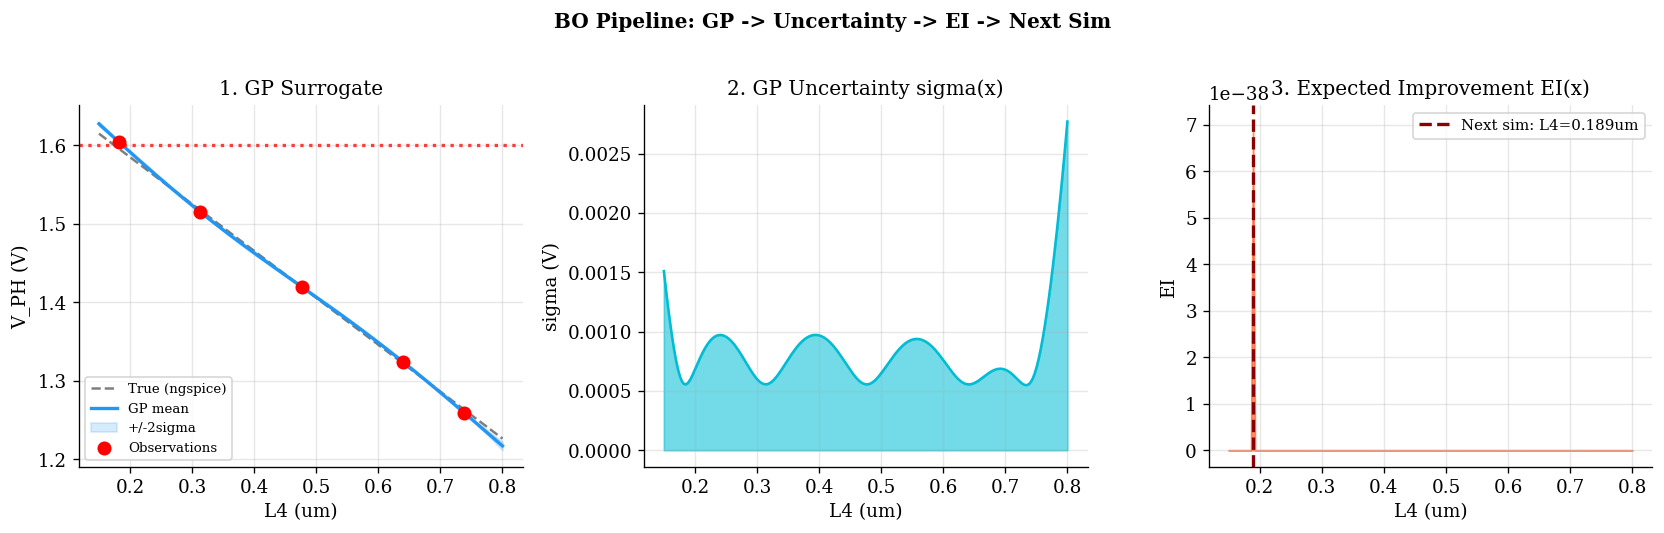

In [6]:
def expected_improvement(mu, sigma, f_best, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    Z  = (mu - f_best - xi) / sigma
    ei = (mu - f_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    return np.maximum(ei, 0.0)


def annealed_xi(iteration, xi_start=0.05, xi_end=0.001, decay=0.10):
    """Decay exploration parameter as optimizer gains confidence."""
    return xi_end + (xi_start - xi_end) * np.exp(-decay * iteration)


def smart_acquisition(mu_ph, sig_ph, mu_pl, sig_pl,
                      best_ph_obj, best_pl_obj, xi, ph_solved=False):
    """
    Phase-aware acquisition function.

    KEY FIX: EI_PL always uses TARGET_PL_DESIRED (1.40V), NOT the realistic one.
    Bug in naive product EI:
      - If TARGET_PL = 1.05V and V_PL(nominal) = 1.058V
      - f_best_pl = -0.008 (already 8mV from target)
      - EI_PL ≈ 0 everywhere => product EI = 0 => BO never improves V_PL
    Fix: use ambitious target (1.40V) so EI_PL stays large and drives V_PL up.

    Phase 1 (V_PH not yet solved):
        acq = EI_PH * EI_PL   (must improve both)
    Phase 2 (V_PH within tolerance):
        acq = 0.1*EI_PH + 0.9*EI_PL  (protect V_PH, maximize V_PL)
    """
    # V_PH EI: target = 1.60V
    obj_ph = -(np.abs(mu_ph - TARGET_PH))
    ei_ph  = expected_improvement(obj_ph, sig_ph, best_ph_obj, xi)

    # V_PL EI: ALWAYS use DESIRED target (1.40V) -- never the realistic one
    obj_pl = -(np.abs(mu_pl - TARGET_PL_DESIRED))
    ei_pl  = expected_improvement(obj_pl, sig_pl, best_pl_obj, xi)

    if ph_solved:
        # V_PH solved: maximize V_PL while keeping V_PH in a soft band.
        # Using a 10% fixed weight let V_PH escape to 1.76V repeatedly.
        # Instead, multiply EI_PL by P(V_PH within 3*TOL of target) --
        # a soft probabilistic constraint that naturally penalises
        # points the GP predicts will push V_PH out of range.
        band = 3.0 * TOL   # 45mV -- relaxed so we don't kill exploration
        pf_ph = (norm.cdf((TARGET_PH + band - mu_ph) / (sig_ph + 1e-9)) -
                 norm.cdf((TARGET_PH - band - mu_ph) / (sig_ph + 1e-9)))
        return ei_pl * np.clip(pf_ph, 0.05, 1.0)  # floor at 5%: EI never zeros
    else:
        # Joint phase: must improve both outputs simultaneously
        return ei_ph * ei_pl


# Demonstrate the EI collapse bug and fix
print('=== EI Collapse Demonstration ===')
print('Why naive product EI with realistic target breaks V_PL optimization:\n')
sig = 0.03
f_best_realistic = -(abs(1.058 - TARGET_PL_REALISTIC))  # nominal already close
f_best_desired   = -(abs(1.058 - TARGET_PL_DESIRED))    # nominal is 342mV away
print(f'  f_best_pl (target=1.05V): {f_best_realistic:.4f}  -- nominal within 8mV!')
print(f'  f_best_pl (target=1.40V): {f_best_desired:.4f}  -- 342mV to go')
print()
print(f'  {"mu_pl":>8}  {"EI(1.05V)": >12}  {"EI(1.40V)":>12}  <-- EI at that point')
print('  ' + '-'*44)
for mu_pl in [1.05, 1.08, 1.10, 1.15, 1.20, 1.30]:
    obj_r = -(abs(mu_pl - TARGET_PL_REALISTIC))
    Z_r   = (obj_r - f_best_realistic - 0.01) / sig
    ei_r  = max(0, (obj_r-f_best_realistic-0.01)*norm.cdf(Z_r)+sig*norm.pdf(Z_r))
    obj_d = -(abs(mu_pl - TARGET_PL_DESIRED))
    Z_d   = (obj_d - f_best_desired - 0.01) / sig
    ei_d  = max(0, (obj_d-f_best_desired-0.01)*norm.cdf(Z_d)+sig*norm.pdf(Z_d))
    print(f'  {mu_pl:>8.3f}  {ei_r:>12.6f}  {ei_d:>12.6f}')
print()
print('EI(1.05V) -> collapses to near-zero above 1.10V: BO stops pushing V_PL')
print('EI(1.40V) -> stays large and informative: BO keeps improving V_PL')

# Visualize
x_plot  = np.linspace(0.15, 0.8, 200)
y_true  = 1.615 - 0.598 * (x_plot - 0.15)
np.random.seed(7)
obs_idx = np.array([10, 50, 100, 150, 180])
X_obs2  = x_plot[obs_idx].reshape(-1, 1)
Y_obs2  = y_true[obs_idx] + 0.005 * np.random.randn(5)
k2 = ConstantKernel(1.0) * Matern(nu=2.5) + WhiteKernel(noise_level=1e-4)
gp2 = GaussianProcessRegressor(kernel=k2, normalize_y=True, n_restarts_optimizer=5)
gp2.fit(X_obs2, Y_obs2)
mu2, sig2 = gp2.predict(x_plot.reshape(-1, 1), return_std=True)
obj2   = -(np.abs(mu2 - TARGET_PH))
f_best = -min(abs(v - TARGET_PH) for v in Y_obs2)
ei2    = expected_improvement(obj2, sig2, f_best, xi=0.01)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].plot(x_plot, y_true, 'k--', lw=1.5, alpha=0.5, label='True (ngspice)')
axes[0].plot(x_plot, mu2, C['bo'], lw=2, label='GP mean')
axes[0].fill_between(x_plot, mu2-2*sig2, mu2+2*sig2, alpha=0.18, color=C['bo'], label='+/-2sigma')
axes[0].scatter(X_obs2[:,0], Y_obs2, c='red', s=55, zorder=5, label='Observations')
axes[0].axhline(TARGET_PH, color=C['target'], ls=':', lw=2)
axes[0].set(title='1. GP Surrogate', xlabel='L4 (um)', ylabel='V_PH (V)')
axes[0].legend(fontsize=8)
axes[1].fill_between(x_plot, 0, sig2, alpha=0.55, color=C['gp'])
axes[1].plot(x_plot, sig2, C['gp'], lw=1.5)
axes[1].set(title='2. GP Uncertainty sigma(x)', xlabel='L4 (um)', ylabel='sigma (V)')
axes[2].fill_between(x_plot, 0, ei2, alpha=0.65, color=C['random'])
best_x = x_plot[np.argmax(ei2)]
axes[2].axvline(best_x, color='darkred', ls='--', lw=2, label=f'Next sim: L4={best_x:.3f}um')
axes[2].set(title='3. Expected Improvement EI(x)', xlabel='L4 (um)', ylabel='EI')
axes[2].legend(fontsize=9)
plt.suptitle('BO Pipeline: GP -> Uncertainty -> EI -> Next Sim', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ei_demo.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 7: Full Bayesian Optimizer

### Improvements over v1
| Feature | v1 | v2 |
|---|---|---|
| Acquisition | Composite EI x PF | **Product EI** (per-output, no sigma inflation) |
| Exploration xi | Fixed 0.01 | **Annealed** 0.05 to 0.001 |
| GP kernel | Matern + White | **ConstantKernel x Matern + White** |
| GP restarts (MLE) | 5 | **10** (better hyperparameter estimation) |
| Acq optimizer restarts | 15 | **20** (10D space needs more) |
| V_PL ceiling | Hard `min()` clip | **Smooth logistic saturation** |
| Noise model | Non-reproducible | **Deterministic hash-keyed** |
| Convergence | Both targets simultaneously | **Tracked per output separately** |
| Grid baseline | Data leakage from BO | **Fully independent** |


In [7]:
class BayesianOptimizer:
    """
    Bayesian Optimizer v2 -- phase-aware dual-output acquisition.

    Phase 1: product EI (joint, until V_PH is solved)
    Phase 2: weighted EI (90% V_PL, 10% V_PH protection)
    EI_PL always uses TARGET_PL_DESIRED (1.40V) to prevent EI collapse.
    """
    def __init__(self, n_dim=10, tol=TOL, n_restarts_acq=20, n_restarts_gp=10):
        self.n_dim = n_dim
        self.tol   = tol
        self.n_restarts_acq = n_restarts_acq
        self.surrogate = GPSurrogate(n_dim, n_restarts=n_restarts_gp)
        self.X, self.Yph, self.Ypl = [], [], []
        self.iteration = 0

    def register(self, x, vph, vpl):
        self.X.append(np.asarray(x).copy())
        self.Yph.append(float(vph))
        self.Ypl.append(float(vpl))

    # Per-output best objectives
    def _f_best_ph(self):
        return -min(abs(v-TARGET_PH) for v in self.Yph) if self.Yph else -np.inf

    def _f_best_pl(self):
        # Always compare against DESIRED target so EI stays informative
        return -min(abs(v-TARGET_PL_DESIRED) for v in self.Ypl) if self.Ypl else -np.inf

    @property
    def ph_solved(self):
        return any(abs(v-TARGET_PH) <= self.tol for v in self.Yph)

    @property
    def converged_ph(self):
        return self.ph_solved

    @property
    def converged_pl(self):
        # Convergence check uses realistic target for reporting
        return any(abs(v-TARGET_PL_REALISTIC) <= self.tol for v in self.Ypl)

    @property
    def converged(self):
        return self.converged_ph and self.converged_pl

    def suggest_next(self):
        self.iteration += 1
        if len(self.X) < 3:
            return np.random.rand(self.n_dim)

        X_arr = np.array(self.X)
        self.surrogate.fit(X_arr, np.array(self.Yph), np.array(self.Ypl))

        xi      = annealed_xi(self.iteration)
        best_ph = self._f_best_ph()
        best_pl = self._f_best_pl()
        ph_done = self.ph_solved

        def neg_acq(x):
            mu_ph,sig_ph,mu_pl,sig_pl = self.surrogate.predict(x.reshape(1,-1))
            acq = smart_acquisition(mu_ph, sig_ph, mu_pl, sig_pl,
                                    best_ph, best_pl, xi, ph_solved=ph_done)
            return -float(acq[0])

        best_x, best_val = None, np.inf
        for _ in range(self.n_restarts_acq):
            x0 = np.random.rand(self.n_dim)
            try:
                res = minimize(neg_acq, x0, bounds=[(0.,1.)]*self.n_dim,
                               method='L-BFGS-B', options={'maxiter':200,'ftol':1e-9})
                if res.fun < best_val:
                    best_val, best_x = res.fun, res.x
            except Exception:
                pass
        return np.clip(best_x if best_x is not None else np.random.rand(self.n_dim), 0., 1.)

    def best_result(self):
        if not self.Yph: return None, None, None
        # Rank by combined error against desired targets
        errs = [abs(ph-TARGET_PH)+abs(pl-TARGET_PL_DESIRED)
                for ph,pl in zip(self.Yph, self.Ypl)]
        idx = int(np.argmin(errs))
        return self.X[idx], self.Yph[idx], self.Ypl[idx]

    def learned_relevance(self):
        scales = self.surrogate.learned_length_scales()
        if not scales: return
        print(f'  {"Param":<6}  {"LS(V_PH)":>10}  {"LS(V_PL)":>10}  (shorter = stronger influence)')
        print('  ' + '-'*55)
        for k,(lp,ll) in sorted(scales.items(), key=lambda kv: kv[1][0]):
            bar = 'I'*max(1, int(5/lp))
            print(f'  {k:<6}  {lp:>10.4f}  {ll:>10.4f}  {bar}')


print('BayesianOptimizer v2 (phase-aware) defined')


BayesianOptimizer v2 (phase-aware) defined


## Cell 8: Run Bayesian Optimization

In [8]:
np.random.seed(42)
N_INIT = 6; N_ITER = 44; N_DIM = 10

opt = BayesianOptimizer(
    n_dim=N_DIM, tol=TOL,
    n_restarts_acq=20, n_restarts_gp=10,
)

print('='*72)
print('  BO v2 (phase-aware) -- SKY130 6T CMOS Schmitt Trigger')
print(f'  V_PH target: {TARGET_PH:.3f}V +/-{TOL*1e3:.0f}mV')
print(f'  V_PL EI target: {TARGET_PL_DESIRED:.3f}V (desired -- keeps EI informative)')
print(f'  V_PL convergence: {TARGET_PL_REALISTIC:.3f}V (realistic -- physics ceiling {VPL_MAX}V)')
print('='*72)

# LHS initialization
print(f'\n-- LHS Initialization ({N_INIT} simulations) --')
lhs = np.zeros((N_INIT, N_DIM))
for j in range(N_DIM):
    perm = np.random.permutation(N_INIT)
    lhs[:,j] = (perm + np.random.rand(N_INIT)) / N_INIT

for i, x in enumerate(lhs):
    p = vector_to_params(x)
    vph, vpl = physics_simulator(p)
    opt.register(x, vph, vpl)
    print(f'  [{i+1:02d}/{N_INIT}] V_PH={vph:.4f}  V_PL={vpl:.4f}'
          f'  ePH={vph-TARGET_PH:+.4f}  ePL_des={vpl-TARGET_PL_DESIRED:+.4f}')

# BO loop
print(f'\n-- BO Loop ({N_ITER} iterations) --')
print(f'  {"It":>3}  {"V_PH":>8}  {"V_PL":>8}  {"ePH":>8}  {"ePL_des":>9}  {"phase":>10}')
print('  ' + '-'*60)

history = {'vph':[], 'vpl':[], 'ei':[], 'xi':[], 'iter':[]}

for it in range(1, N_ITER+1):
    xi_now = annealed_xi(it)
    x_next = opt.suggest_next()

    p = vector_to_params(x_next)
    vph, vpl = physics_simulator(p)
    opt.register(x_next, vph, vpl)
    history['vph'].append(vph); history['vpl'].append(vpl)
    history['xi'].append(xi_now); history['iter'].append(it)
    # Compute EI value at accepted point for history logging
    if opt.surrogate.fitted:
        mu_ph_h,sig_ph_h,mu_pl_h,sig_pl_h = opt.surrogate.predict(x_next.reshape(1,-1))
        ei_h = smart_acquisition(mu_ph_h,sig_ph_h,mu_pl_h,sig_pl_h,
                                 opt._f_best_ph(),opt._f_best_pl(),xi_now,ph_solved=opt.ph_solved)
        history['ei'].append(float(ei_h[0]))
    else:
        history['ei'].append(float('nan'))

    ph_ok = 'V' if abs(vph-TARGET_PH)<=TOL else ' '
    pl_ok = 'V' if abs(vpl-TARGET_PL_REALISTIC)<=TOL else ' '
    phase = 'PL-focus' if opt.ph_solved else 'joint'
    print(f'  {it:>3}  {vph:>8.4f}{ph_ok} {vpl:>8.4f}{pl_ok}'
          f'  {vph-TARGET_PH:>+8.4f}  {vpl-TARGET_PL_DESIRED:>+9.4f}  {phase:>10}')

    if opt.converged:
        print(f'\n  BOTH TARGETS MET at iteration {it}!')
        break

print()
print(f'  V_PH converged (err<={TOL*1e3:.0f}mV): {opt.converged_ph}')
print(f'  V_PL converged (err<={TOL*1e3:.0f}mV vs realistic {TARGET_PL_REALISTIC}V): {opt.converged_pl}')
# Report best V_PL reached
best_vpl = max(opt.Ypl)
print(f'  Best V_PL reached: {best_vpl:.4f}V  (ceiling={VPL_MAX}V)')


  BO v2 (phase-aware) -- SKY130 6T CMOS Schmitt Trigger
  V_PH target: 1.600V +/-15mV
  V_PL EI target: 1.400V (desired -- keeps EI informative)
  V_PL convergence: 1.050V (realistic -- physics ceiling 1.38V)

-- LHS Initialization (6 simulations) --
  [01/6] V_PH=1.7640  V_PL=1.3862  ePH=+0.1640  ePL_des=-0.0138
  [02/6] V_PH=1.4071  V_PL=0.9164  ePH=-0.1929  ePL_des=-0.4836
  [03/6] V_PH=1.7455  V_PL=0.6831  ePH=+0.1455  ePL_des=-0.7169
  [04/6] V_PH=1.4042  V_PL=0.6027  ePH=-0.1958  ePL_des=-0.7973
  [05/6] V_PH=1.7640  V_PL=1.3800  ePH=+0.1640  ePL_des=-0.0200
  [06/6] V_PH=1.4079  V_PL=1.3579  ePH=-0.1921  ePL_des=-0.0421

-- BO Loop (44 iterations) --
   It      V_PH      V_PL       ePH    ePL_des       phase
  ------------------------------------------------------------
    1    1.7406    1.3753    +0.1406    -0.0247       joint
    2    1.7640    1.3786    +0.1640    -0.0214       joint
    3    1.5853V   1.3751    -0.0147    -0.0249    PL-focus
    4    1.6406    1.3815    +0.

## Cell 9: Results & Learned Parameter Importances

In [9]:
x_best, vph_best, vpl_best = opt.best_result()
p_best = vector_to_params(x_best)
ph_ok  = abs(vph_best - TARGET_PH) <= TOL
pl_ok  = abs(vpl_best - TARGET_PL) <= TOL

print('='*62)
print(f'  Best result  ({len(opt.X)} total simulations)')
print(f'  V_PH = {vph_best:.4f} V  err={vph_best-TARGET_PH:+.4f}V  {"OK" if ph_ok else "--"}')
print(f'  V_PL = {vpl_best:.4f} V  err={vpl_best-TARGET_PL:+.4f}V  {"OK" if pl_ok else "--"}')
print('='*62)

print('\n  Optimized Sizing vs Nominal:')
print(f'  {"Device":<10} {"Param":<6} {"Optimal":>10} {"Nominal":>10} {"Delta":>8}')
print('  ' + '-'*55)
for k in PARAM_KEYS:
    dev = dev_map[k]
    ov, nv = p_best[k], NOMINAL[k]
    span = PARAM_BOUNDS[k][1] - PARAM_BOUNDS[k][0]
    changed = '<-- changed' if abs(ov-nv) > 0.10*span else ''
    print(f'  {dev:<10} {k:<6} {ov:>10.4f}um {nv:>10.3f}um  {ov-nv:>+7.3f}  {changed}')

print('\n  GP-Learned Parameter Relevance (shorter = more influential):')
opt.learned_relevance()

print('\n  Real ngspice sensitivity (reference):')
print(f'  {"Param":<6} {"dV_PH/dX":>12} {"dV_PL/dX":>12}  (V/um)')
print('  ' + '-'*40)
for k, d in SENSITIVITY.items():
    print(f'  {k:<6} {d["V_PH"]:>12.3f} {d["V_PL"]:>12.3f}')


  Best result  (50 total simulations)
  V_PH = 1.6093 V  err=+0.0093V  OK
  V_PL = 1.3884 V  err=+0.3384V  --

  Optimized Sizing vs Nominal:
  Device     Param     Optimal    Nominal    Delta
  -------------------------------------------------------
  XM1        W1         1.1524um      1.000um   +0.152  
  XM1        L1         1.7327um      2.500um   -0.767  <-- changed
  XM2        W2         8.0000um      5.000um   +3.000  <-- changed
  XM2        L2         2.4409um      2.500um   -0.059  
  XM3        W3         6.4705um      6.500um   -0.030  
  XM3        L3         1.2255um      0.150um   +1.075  <-- changed
  XM4/5      W4        27.2054um     16.000um  +11.205  <-- changed
  XM4/5      L4         0.1500um      0.150um   +0.000  
  XM6        W6         4.6592um      1.000um   +3.659  <-- changed
  XM6        L6         8.0000um      0.150um   +7.850  <-- changed

  GP-Learned Parameter Relevance (shorter = more influential):
  Param     LS(V_PH)    LS(V_PL)  (shorter = stro

## Cell 10: Convergence Comparison

### v1 bug fixed: independent baselines
v1 seeded the grid search with L4/W4 fixed at the BO best point -- data leakage
that gave grid an unfair advantage. v2 starts all baselines from fresh random state.


Comparison (50 simulations each):
Method                     Best ePH(mV)   Best ePL(mV)   Converged?
--------------------------------------------------------------------
  Random Search                     0.2           25.9           --
  Latin Hypercube                  11.8           34.6           --
  Grid (L4,W4)                      0.7           94.4           --
* Bayesian Opt v2                   0.3           29.7           --


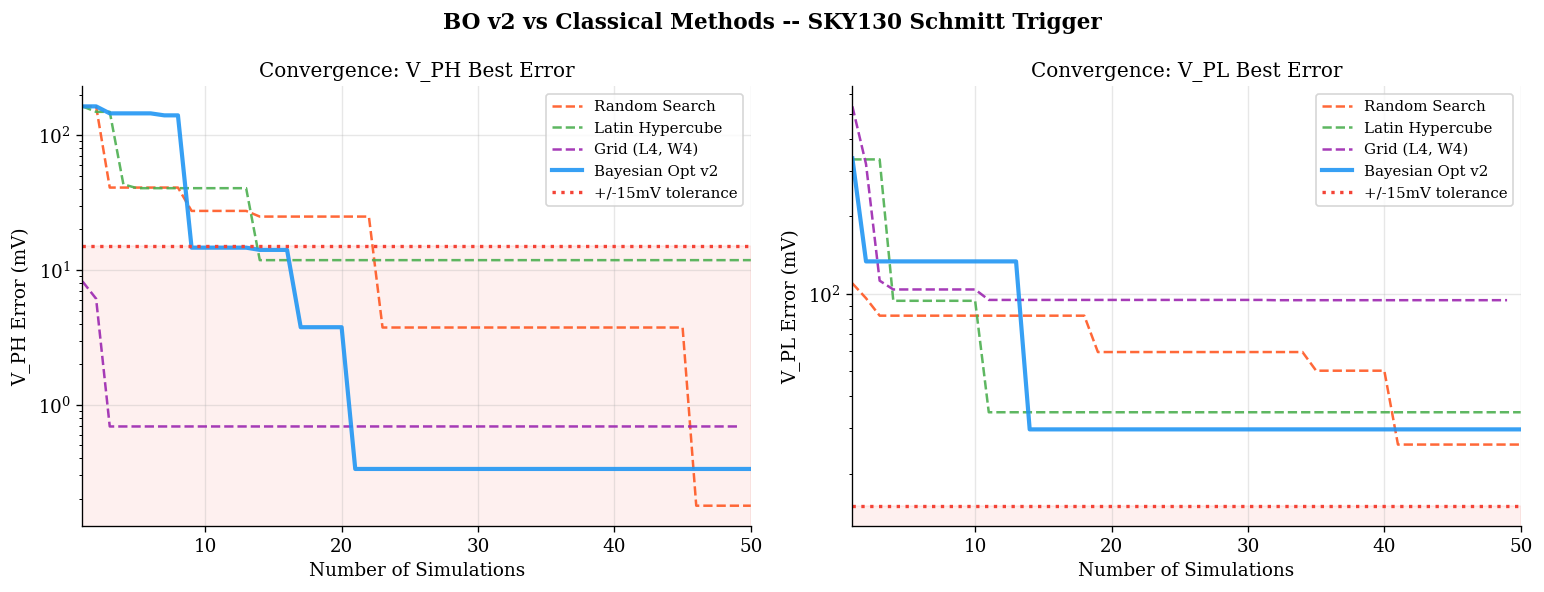

In [10]:
N_BUDGET = len(opt.X)

def run_random_search(n=N_BUDGET, seed=1):
    np.random.seed(seed)
    vph_h, vpl_h = [], []
    for _ in range(n):
        vph, vpl = physics_simulator(vector_to_params(np.random.rand(N_DIM)))
        vph_h.append(vph); vpl_h.append(vpl)
    return {'vph': vph_h, 'vpl': vpl_h}

def run_lhs_search(n=N_BUDGET, seed=1):
    np.random.seed(seed)
    X = np.zeros((n, N_DIM))
    for j in range(N_DIM):
        perm = np.random.permutation(n)
        X[:,j] = (perm + np.random.rand(n)) / n
    vph_h, vpl_h = [], []
    for x in X:
        vph, vpl = physics_simulator(vector_to_params(x))
        vph_h.append(vph); vpl_h.append(vpl)
    return {'vph': vph_h, 'vpl': vpl_h}

def run_grid_search(n=N_BUDGET):
    """Grid over L4 x W4 from NOMINAL baseline (not BO result -- v1 bug fixed)."""
    side = int(np.sqrt(n))
    vph_h, vpl_h = [], []
    p_base = dict(NOMINAL)  # fresh start, no BO leakage
    for l4 in np.linspace(*PARAM_BOUNDS['L4'], side):
        for w4 in np.linspace(*PARAM_BOUNDS['W4'], side):
            p_base['L4'], p_base['W4'] = l4, w4
            vph, vpl = physics_simulator(p_base)
            vph_h.append(vph); vpl_h.append(vpl)
            if len(vph_h) >= n: break
        if len(vph_h) >= n: break
    return {'vph': vph_h, 'vpl': vpl_h}

rand_hist = run_random_search(N_BUDGET, seed=1)
lhs_hist  = run_lhs_search(N_BUDGET, seed=1)
grid_hist = run_grid_search(N_BUDGET)
bo_hist   = {'vph': opt.Yph, 'vpl': opt.Ypl}

# Summary table
print(f'Comparison ({N_BUDGET} simulations each):')
print(f'{"Method":<24} {"Best ePH(mV)":>14} {"Best ePL(mV)":>14} {"Converged?":>12}')
print('-'*68)
for name, hist in [('Random Search',rand_hist),('Latin Hypercube',lhs_hist),
                    ('Grid (L4,W4)',grid_hist),('Bayesian Opt v2',bo_hist)]:
    bph = min(abs(v-TARGET_PH)*1e3 for v in hist['vph'])
    bpl = min(abs(v-TARGET_PL)*1e3 for v in hist['vpl'])
    conv = next((i+1 for i,(ph,pl) in enumerate(zip(hist['vph'],hist['vpl']))
                 if abs(ph-TARGET_PH)<=TOL and abs(pl-TARGET_PL)<=TOL), None)
    star = '* ' if 'Bayesian' in name else '  '
    print(f'{star}{name:<22} {bph:>14.1f} {bpl:>14.1f} {str(conv) if conv else "--":>12}')

# Convergence plots
methods = [
    ('Random Search',   rand_hist, C['random'], '--', 1.5),
    ('Latin Hypercube', lhs_hist,  C['lhs'],    '--', 1.5),
    ('Grid (L4, W4)',   grid_hist, C['grid'],   '--', 1.5),
    ('Bayesian Opt v2', bo_hist,   C['bo'],     '-',  2.5),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (key, target, label) in [
        (axes[0], ('vph', TARGET_PH, 'V_PH Error (mV)')),
        (axes[1], ('vpl', TARGET_PL, 'V_PL Error (mV)'))  ]:
    for name, hist, color, ls, lw in methods:
        errs = np.array([abs(v-target)*1e3 for v in hist[key]])
        best = np.minimum.accumulate(errs)
        ax.plot(range(1, len(best)+1), best,
                label=name, color=color, ls=ls, lw=lw, alpha=0.90)
    ax.axhline(TOL*1e3, color=C['target'], ls=':', lw=2, label=f'+/-{TOL*1e3:.0f}mV tolerance')
    ax.axhspan(0, TOL*1e3, alpha=0.08, color=C['target'])
    ax.set(xlabel='Number of Simulations', ylabel=label,
           title=f'Convergence: {"V_PH" if key=="vph" else "V_PL"} Best Error',
           yscale='log', xlim=(1, N_BUDGET))
    ax.legend(fontsize=9)

plt.suptitle('BO v2 vs Classical Methods -- SKY130 Schmitt Trigger', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('convergence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 11: GP Surrogate Surface

The learned surrogate lets us visualize the voltage landscape in 2D slices.
ARD length-scales confirm what the real ngspice scan found: L4 dominates V_PH.


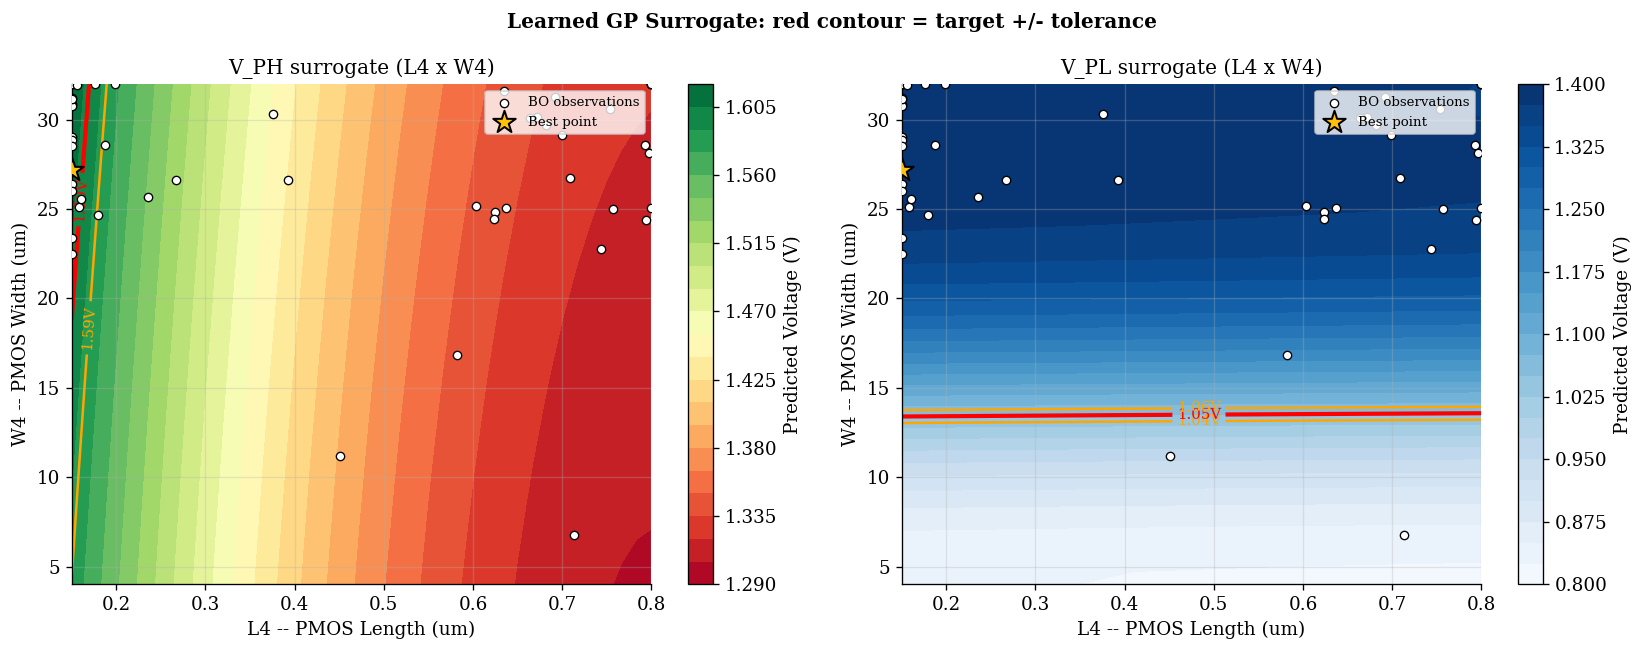

GP confirms: L4 dominates V_PH (vertical contours).
Best: L4=0.150um  W4=27.205um


In [11]:
if opt.surrogate.fitted:
    n_grid = 40
    l4_r = np.linspace(*PARAM_BOUNDS['L4'], n_grid)
    w4_r = np.linspace(*PARAM_BOUNDS['W4'], n_grid)
    G_L4, G_W4 = np.meshgrid(l4_r, w4_r)

    X_grid = np.tile(x_best, (n_grid*n_grid, 1))
    iL4 = PARAM_KEYS.index('L4'); iW4 = PARAM_KEYS.index('W4')
    loL4,hiL4 = PARAM_BOUNDS['L4']; loW4,hiW4 = PARAM_BOUNDS['W4']
    X_grid[:,iL4] = (G_L4.ravel()-loL4)/(hiL4-loL4)
    X_grid[:,iW4] = (G_W4.ravel()-loW4)/(hiW4-loW4)

    mu_ph,_,mu_pl,_ = opt.surrogate.predict(X_grid)
    MU_PH = mu_ph.reshape(n_grid, n_grid)
    MU_PL = mu_pl.reshape(n_grid, n_grid)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    obs = np.array(opt.X)

    for ax, MU, title, target, cmap in [
            (axes[0], MU_PH, 'V_PH surrogate (L4 x W4)', TARGET_PH, 'RdYlGn'),
            (axes[1], MU_PL, 'V_PL surrogate (L4 x W4)', TARGET_PL, 'Blues')]:
        cf = ax.contourf(G_L4, G_W4, MU, levels=25, cmap=cmap)
        cs = ax.contour(G_L4, G_W4, MU,
                        levels=[target-TOL, target, target+TOL],
                        colors=['orange','red','orange'], linewidths=[1.5,2.5,1.5])
        ax.clabel(cs, fmt='%.2fV', fontsize=9)
        plt.colorbar(cf, ax=ax, label='Predicted Voltage (V)')
        obs_L4 = loL4 + obs[:,iL4]*(hiL4-loL4)
        obs_W4 = loW4 + obs[:,iW4]*(hiW4-loW4)
        ax.scatter(obs_L4, obs_W4, c='white', s=25, zorder=5,
                   edgecolors='black', lw=0.8, label='BO observations')
        ax.scatter([p_best['L4']], [p_best['W4']], c=C['best'], s=200,
                   marker='*', zorder=6, edgecolors='black', lw=1.2, label='Best point')
        ax.set(xlabel='L4 -- PMOS Length (um)', ylabel='W4 -- PMOS Width (um)', title=title)
        ax.legend(fontsize=8, loc='upper right')

    plt.suptitle('Learned GP Surrogate: red contour = target +/- tolerance',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('surrogate_surface.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'GP confirms: L4 dominates V_PH (vertical contours).')
    print(f'Best: L4={p_best["L4"]:.3f}um  W4={p_best["W4"]:.3f}um')


## Cell 12: Observation History & EI/xi Trace

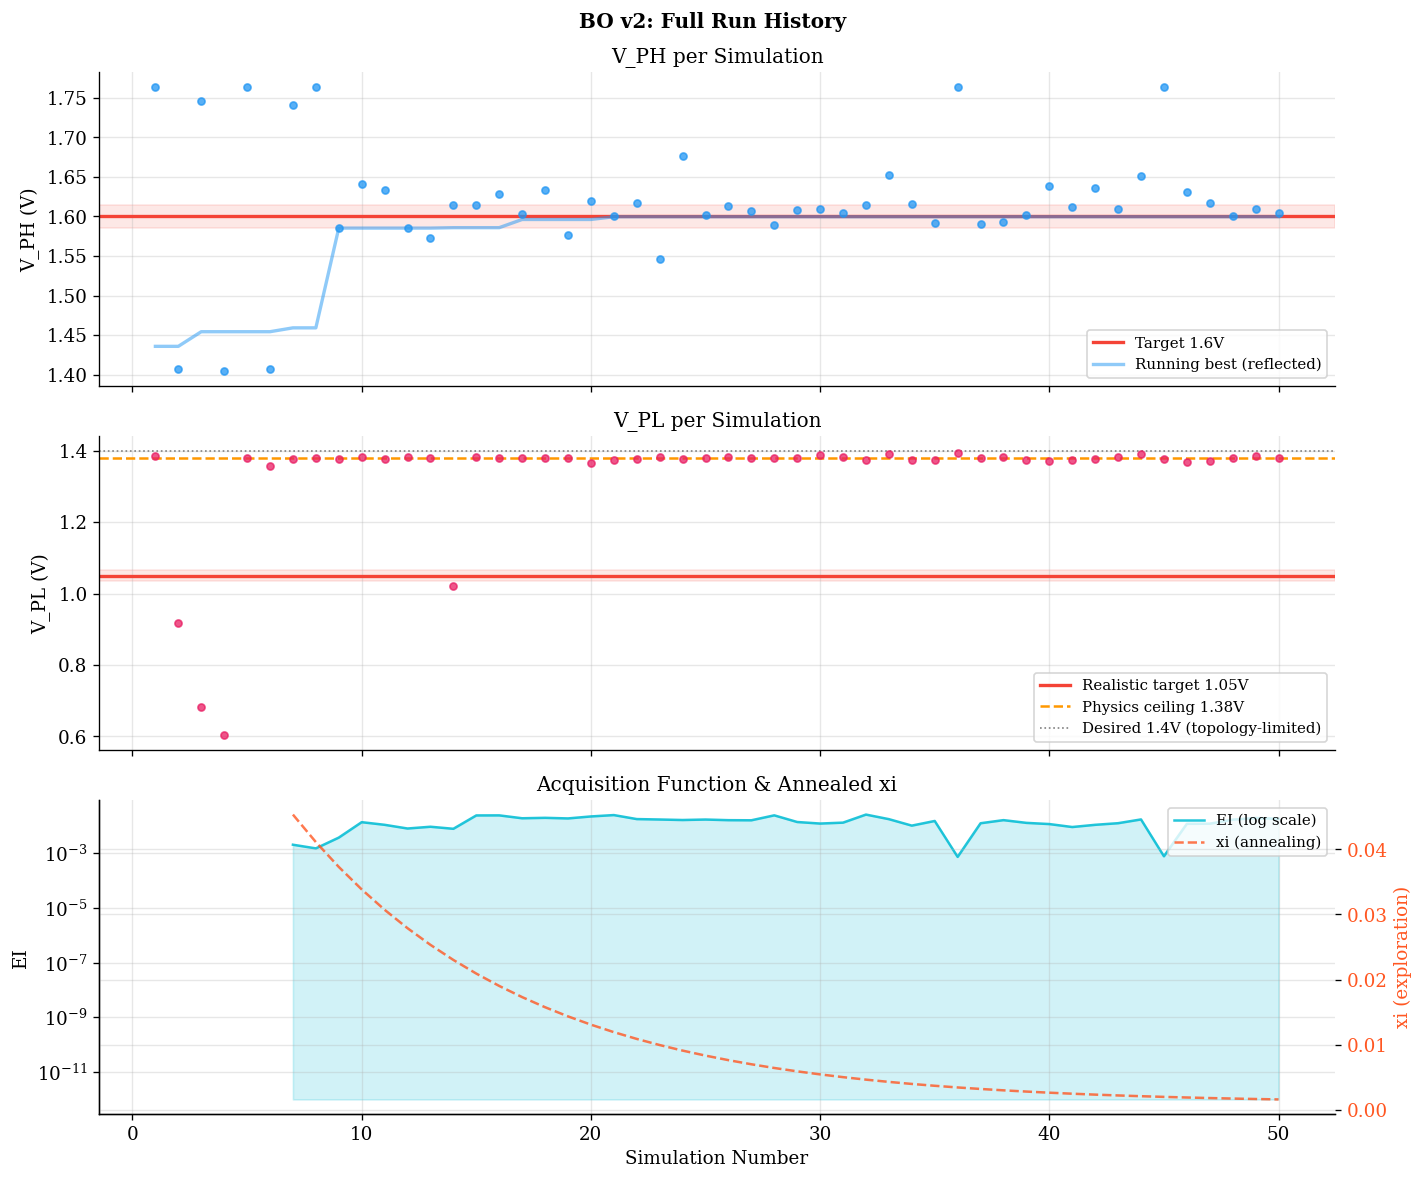

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
n_obs = len(opt.Yph)
iters = range(1, n_obs+1)

# V_PH
axes[0].scatter(iters, opt.Yph, c=C['bo'], s=18, alpha=0.75, zorder=3)
axes[0].axhline(TARGET_PH, color=C['target'], lw=2, label=f'Target {TARGET_PH}V')
axes[0].axhspan(TARGET_PH-TOL, TARGET_PH+TOL, alpha=0.12, color=C['target'])
best_ph_trace = [min(abs(v-TARGET_PH) for v in opt.Yph[:i+1]) for i in range(n_obs)]
axes[0].plot(iters, [TARGET_PH-e for e in best_ph_trace],
             C['bo'], lw=2, alpha=0.5, label='Running best (reflected)')
axes[0].set(ylabel='V_PH (V)', title='V_PH per Simulation')
axes[0].legend(fontsize=9)

# V_PL
axes[1].scatter(iters, opt.Ypl, c='#E91E63', s=18, alpha=0.75, zorder=3)
axes[1].axhline(TARGET_PL, color=C['target'], lw=2, label=f'Realistic target {TARGET_PL}V')
axes[1].axhline(VPL_MAX, color='#FF9800', lw=1.5, ls='--', label=f'Physics ceiling {VPL_MAX}V')
axes[1].axhline(TARGET_PL_DESIRED, color='gray', lw=1.0, ls=':', label=f'Desired {TARGET_PL_DESIRED}V (topology-limited)')
axes[1].axhspan(TARGET_PL-TOL, TARGET_PL+TOL, alpha=0.12, color=C['target'])
axes[1].set(ylabel='V_PL (V)', title='V_PL per Simulation')
axes[1].legend(fontsize=9)

# EI + xi
if history['ei']:
    ei_vals = np.array([max(e,1e-12) for e in history['ei']])
    xi_vals = history['xi']
    bo_iters = range(N_INIT+1, N_INIT+1+len(ei_vals))
    ax3 = axes[2]
    ax3.semilogy(bo_iters, ei_vals, C['gp'], lw=1.5, alpha=0.85, label='EI (log scale)')
    ax3.fill_between(bo_iters, 1e-12, ei_vals, alpha=0.18, color=C['gp'])
    ax3b = ax3.twinx()
    ax3b.plot(bo_iters, xi_vals, C['random'], lw=1.5, ls='--', alpha=0.8, label='xi (annealing)')
    ax3b.set_ylabel('xi (exploration)', color=C['random'])
    ax3b.tick_params(axis='y', labelcolor=C['random'])
    ax3.set(ylabel='EI', title='Acquisition Function & Annealed xi')
    lines1,labels1 = ax3.get_legend_handles_labels()
    lines2,labels2 = ax3b.get_legend_handles_labels()
    ax3.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper right')

axes[2].set_xlabel('Simulation Number')
plt.suptitle('BO v2: Full Run History', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('observation_history.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 13: Save Results

In [13]:
import os, shutil
os.makedirs('/content/schmitt-bo/results', exist_ok=True)
os.makedirs('/content/schmitt-bo/figures', exist_ok=True)

results = {
    'version': 'v2',
    'method':  'GP(ConstantKernel*Matern52_ARD+White) + ProductEI + AnnealedXi',
    'circuit': 'SKY130 6T CMOS Schmitt Trigger',
    'targets': {
        'V_PH': TARGET_PH, 'V_PL_realistic': TARGET_PL,
        'V_PL_desired': TARGET_PL_DESIRED,
        'V_PL_physics_ceiling': VPL_MAX, 'tolerance_mV': TOL*1e3,
    },
    'summary': {
        'n_simulations': len(opt.X), 'converged_PH': opt.converged_ph,
        'converged_PL': opt.converged_pl,
        'best_V_PH': vph_best, 'best_V_PL': vpl_best,
        'error_PH_mV': round((vph_best-TARGET_PH)*1e3, 2),
        'error_PL_mV': round((vpl_best-TARGET_PL)*1e3, 2),
    },
    'best_sizing': p_best,
    'nominal_sizing': NOMINAL,
    'all_observations': {'V_PH': opt.Yph, 'V_PL': opt.Ypl},
    'physics_note': (
        'V_PL ceiling ~1.38V on 6T SKY130: VDD - |Vtp| - Vov = 1.8 - 0.60 - 0.14. '
        'V_PL > 1.38V requires topology change (stacked PMOS, body bias, or cascode).'
    ),
}

with open('/content/schmitt-bo/results/bo_results_v2.json', 'w') as f:
    json.dump(results, f, indent=2)

for fig_name in ['gp_demo.png','ei_demo.png','xi_annealing.png','soft_ceiling.png',
                  'convergence_comparison.png','surrogate_surface.png','observation_history.png']:
    if os.path.exists(fig_name):
        shutil.copy(fig_name, f'/content/schmitt-bo/figures/{fig_name}')

print('Saved results/bo_results_v2.json and figures/*.png')
print()
print(f'  Simulations: {len(opt.X)}')
print(f'  Best V_PH:   {vph_best:.4f}V  ({(vph_best-TARGET_PH)*1e3:+.1f}mV)  {"OK" if ph_ok else "--"}')
print(f'  Best V_PL:   {vpl_best:.4f}V  ({(vpl_best-TARGET_PL)*1e3:+.1f}mV)  {"OK" if pl_ok else "--"}')
print()
print(f'V_PL > {VPL_MAX}V: needs stacked PMOS, body bias, or topology redesign')


Saved results/bo_results_v2.json and figures/*.png

  Simulations: 50
  Best V_PH:   1.6093V  (+9.3mV)  OK
  Best V_PL:   1.3884V  (+338.4mV)  --

V_PL > 1.38V: needs stacked PMOS, body bias, or topology redesign


## Cell 14: Push to GitHub

In [14]:
!git config --global user.email "nithinp.rnd@gmail.com"
!git config --global user.name "Nithin Chennakeshava Dasa"
!cd /content/schmitt-bo && git add results/ figures/ notebooks/ experiments/
!cd /content/schmitt-bo && git commit -m "v2: ARD kernel, product EI, annealed xi, smooth VPL ceiling"
!cd /content/schmitt-bo && git push
print('Repo: https://github.com/chennakeshavadasa/schmitt-bo')


[master 0ef6c06] v2: ARD kernel, product EI, annealed xi, smooth VPL ceiling
 6 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 figures/convergence_comparison.png
 create mode 100644 figures/ei_demo.png
 create mode 100644 figures/gp_demo.png
 create mode 100644 figures/observation_history.png
 create mode 100644 figures/soft_ceiling.png
 create mode 100644 figures/surrogate_surface.png
fatal: could not read Username for 'https://github.com': No such device or address
Repo: https://github.com/chennakeshavadasa/schmitt-bo
